# IMDB Movie Revenue Prediction (Modified)
Step by step: data load -> log-transform target -> scale features -> train -> evaluate -> visualize

## Step 1: Import & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

imbd = pd.read_csv("imdb_movie_dataset.csv")
imbd.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## Step 2: Select columns & handle missing values

In [3]:
cols = ['Title','Genre','Director','Actors','Rating', 'Votes', 'Runtime (Minutes)',
        'Metascore', 'Revenue (Millions)']

data = imbd[cols].dropna()
print("Shape after dropna:", data.shape)
data.isnull().sum()

Shape after dropna: (838, 9)


Title                 0
Genre                 0
Director              0
Actors                0
Rating                0
Votes                 0
Runtime (Minutes)     0
Metascore             0
Revenue (Millions)    0
dtype: int64

## Step 3: Log-transform the target (Revenue is right-skewed)

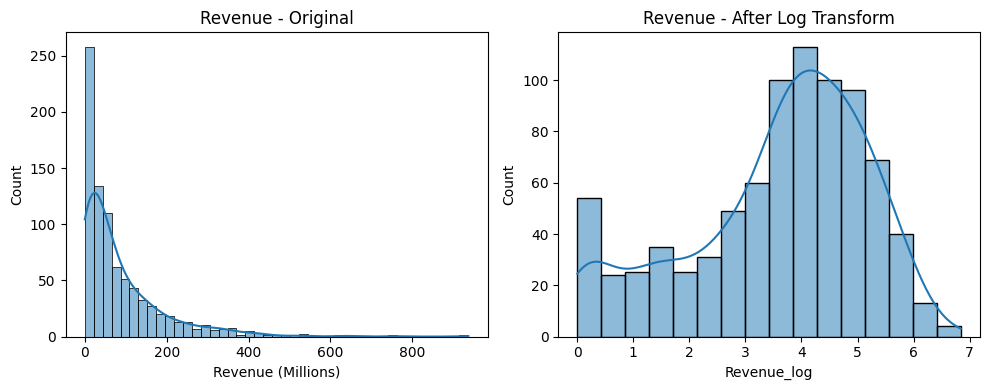

In [4]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sb.histplot(data['Revenue (Millions)'], kde=True)
plt.title("Revenue - Original")

# log1p transform (handles 0 values safely)
data['Revenue_log'] = np.log1p(data['Revenue (Millions)'])

plt.subplot(1,2,2)
sb.histplot(data['Revenue_log'], kde=True)
plt.title("Revenue - After Log Transform")
plt.tight_layout()
plt.show()

## Step 4: Define X and y (use log target)

In [5]:
X = data[['Rating', 'Votes', 'Runtime (Minutes)', 'Metascore']]
y = data['Revenue_log']   # log-transformed target

print(X.shape)
print(y.shape)

(838, 4)
(838,)


## Step 5: Train-test split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2
)

## Step 6: Feature scaling (Standardization)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 7: Fit the model

In [8]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 8: Prediction + inverse log transform

In [9]:
y_pred_log = lm.predict(X_test_scaled)

# convert back to original scale
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

y_pred[:5]

array([ 56.86310211,  26.02975452,  50.60696852,  55.95627106,
       256.73174443])

## Step 9: Evaluation metrics (original revenue scale)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# R2 on log scale as well (model was actually fit on this)
r2_log = r2_score(y_test, y_pred_log)
print("R2 Score (log scale):", r2_log)

MSE: 21350.692244914353
RMSE: 146.11876075615461
R2 Score: -0.8300292649453167
R2 Score (log scale): 0.39170180048183667


## Step 10: Feature coefficients (now scaled, comparable)

In [11]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lm.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coefficients)
print("Intercept:", lm.intercept_)

             Feature  Coefficient
1              Votes     1.021051
0             Rating    -0.270550
3          Metascore    -0.150525
2  Runtime (Minutes)     0.093577
Intercept: 3.6304717275068366


## Step 11: Actual vs Predicted table

In [12]:
result = pd.DataFrame({
    "Actual Revenue": y_test_actual.values,
    "Predicted Revenue": y_pred
})
print(result.head(10))

   Actual Revenue  Predicted Revenue
0           55.09          56.863102
1           10.10          26.029755
2          126.98          50.606969
3          209.81          55.956271
4          423.03         256.731744
5            2.20          14.482511
6            2.41          36.867419
7           12.63          21.016259
8           35.27          30.893109
9            1.82          16.934262


## Step 12: Plot - Actual vs Predicted

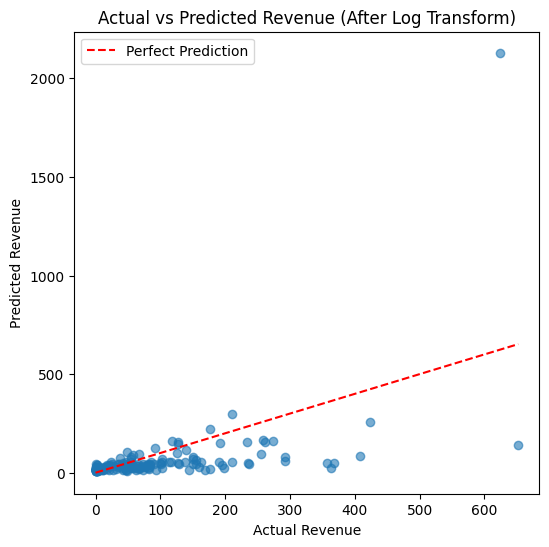

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred, alpha=0.6)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', label="Perfect Prediction")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue (After Log Transform)")
plt.legend()
plt.show()

In [14]:
# Scale X
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)


# Prediction
y_pred = model.predict(X_test_scaled)


# Evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


# Actual vs Predicted
result = pd.DataFrame({
    "Actual Revenue": y_test.values,
    "Predicted Revenue": y_pred
})

print(result.head(10))

MSE: 1.8963953126112498
RMSE: 1.3770966968994043
R2 Score: 0.39170180048183667
   Actual Revenue  Predicted Revenue
0        4.026958           4.058080
1        2.406945           3.296938
2        4.851874           3.943657
3        5.350957           4.042284
4        6.049804           5.551919
5        1.163151           2.739711
6        1.226712           3.634091
7        2.612273           3.091781
8        3.590991           3.462390
9        1.036737           2.886713
